In [1]:
import numpy as np
import pandas as pd

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.data.fetch_nasa_omni_historical import load_and_clean_nasa_omni_historical, load_and_clean_nasa_omni_historical_for_years
from src.features.transformers import SolarWindTransformer
from src.features.preprocessing import SolarWindPreprocessor, DataValidator
from src.models.train import train_and_test_on_temporal_splits, evaluate_on_temporal_splits, evaluate_storm_predictions

Get data for years 1995 to 2024 as separate dataframes

In [2]:
years = list(range(1995, 2024))
dfs = load_and_clean_nasa_omni_historical_for_years(years)

2026-03-21 21:02:16,545 - INFO - Found existing raw data file for year 1995 at data/raw/omni2_1995_raw.csv. Loading...
2026-03-21 21:02:16,561 - INFO - Found existing raw data file for year 1996 at data/raw/omni2_1996_raw.csv. Loading...
2026-03-21 21:02:16,576 - INFO - Found existing raw data file for year 1997 at data/raw/omni2_1997_raw.csv. Loading...
2026-03-21 21:02:16,587 - INFO - Found existing raw data file for year 1998 at data/raw/omni2_1998_raw.csv. Loading...
2026-03-21 21:02:16,597 - INFO - Found existing raw data file for year 1999 at data/raw/omni2_1999_raw.csv. Loading...
2026-03-21 21:02:16,605 - INFO - Found existing raw data file for year 2000 at data/raw/omni2_2000_raw.csv. Loading...
2026-03-21 21:02:16,613 - INFO - Found existing raw data file for year 2001 at data/raw/omni2_2001_raw.csv. Loading...
2026-03-21 21:02:16,620 - INFO - Found existing raw data file for year 2002 at data/raw/omni2_2002_raw.csv. Loading...
2026-03-21 21:02:16,628 - INFO - Found existing 

In [3]:
preprocessor = SolarWindPreprocessor()
preprocessed_Xs = []
preprocessed_ys = []
for df in dfs:
    (X, y) = preprocessor.preprocess(df, scale=False)
    y_bin = y >= 50
    y_bin.name = 'Is_Storm'
    # y.drop(columns=['Kp_index'], inplace=True)
    preprocessed_Xs.append(X)
    preprocessed_ys.append(y_bin)

target_col = 'Is_Storm'

2026-03-21 21:02:19,701 - INFO - Initialized SolarWindPreprocessor with standard scaler
2026-03-21 21:02:19,702 - INFO - === STARTING PREPROCESSING PIPELINE ===
2026-03-21 21:02:19,704 - INFO - Engineering features...
2026-03-21 21:02:19,709 - INFO - Features after engineering: 22
2026-03-21 21:02:19,710 - INFO - Selecting 15 features...
2026-03-21 21:02:19,711 - INFO - Selected features shape: (8760, 16)
2026-03-21 21:02:19,711 - INFO - Handling missing values with method: interpolate
2026-03-21 21:02:19,716 - INFO - Missing values reduced from 8 to 0
2026-03-21 21:02:19,717 - INFO - Features shape: (8758, 15), Target shape: (8758,)
2026-03-21 21:02:19,717 - INFO - === PREPROCESSING COMPLETE ===

2026-03-21 21:02:19,718 - INFO - === STARTING PREPROCESSING PIPELINE ===
2026-03-21 21:02:19,718 - INFO - Engineering features...
2026-03-21 21:02:19,725 - INFO - Features after engineering: 22
2026-03-21 21:02:19,725 - INFO - Selecting 15 features...
2026-03-21 21:02:19,727 - INFO - Selected

In [4]:
for df in preprocessed_Xs:
    DataValidator.validate_data_stats(df)

2026-03-21 21:02:22,176 - INFO - 
--- Data Statistics ---
2026-03-21 21:02:22,177 - INFO - Shape: (8758, 15)
2026-03-21 21:02:22,179 - INFO - Memory usage: 1.12 MB
2026-03-21 21:02:22,204 - INFO - 
Descriptive stats:
               DOY         Hour      IMF_Mag  Plasma_Speed  Proton_Density  \
count  8758.000000  8758.000000  8758.000000   8758.000000     8758.000000   
mean    183.041562    11.502512     0.030281    428.337006        8.769673   
std     105.348172     6.921372     3.382748    109.407019        6.432642   
min       1.000000     0.000000   -15.600000    253.000000        0.600000   
25%      92.000000     6.000000    -2.600000    345.000000        4.100000   
50%     183.000000    12.000000    -0.100000    394.000000        7.000000   
75%     274.000000    17.750000     2.600000    488.000000       11.600000   
max     365.000000    23.000000    13.100000    766.000000       59.900000   

            By_GSE       Bz_GSE  Energy_Flux      B_total    B_azimuth  \
count 

## XGBoost

Here we tune hyperparameters on XGBClassifiers with Optua

In [5]:
import optuna
from xgboost import XGBClassifier
from src.models.train import class_weight_across_folds, train_on_temporal_splits, test_on_temporal_splits

# if "XGBClassifier" not in globals():

# if "class_weight_across_folds" not in globals() or "train_on_temporal_splits" not in globals() or "test_on_temporal_splits" not in globals():


def _extract_metric(summary, candidates):
    # Supports dict / Series / 1-row DataFrame from evaluate_on_temporal_splits
    if isinstance(summary, dict):
        for k in candidates:
            if k in summary:
                return float(summary[k])
    if hasattr(summary, "to_dict"):
        d = summary.to_dict()
        # Series-like
        if isinstance(d, dict):
            for k in candidates:
                if k in d:
                    return float(d[k])
            # DataFrame-like: {col: {idx: val}}
            for k in candidates:
                if k in d and isinstance(d[k], dict) and len(d[k]) > 0:
                    return float(next(iter(d[k].values())))
    if hasattr(summary, "columns"):  # DataFrame-like
        for k in candidates:
            if k in summary.columns:
                return float(summary[k].iloc[0])
    return None


scale_weight = class_weight_across_folds(preprocessed_ys)


def objective(trial):
    max_depth = trial.suggest_int("max_depth", 2, 8)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    prob_thres = trial.suggest_float("prob_threshold", 0.50, 0.95)

    params = {
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "scale_pos_weight": scale_weight,
        "eval_metric": "logloss",
        "random_state": 42,
    }

    models = train_on_temporal_splits(XGBClassifier, params, preprocessed_Xs, preprocessed_ys)
    preds = test_on_temporal_splits(models, preprocessed_Xs, preprocessed_ys, prob_thres)
    summary = evaluate_on_temporal_splits(preds)

    mean_precision = summary['Mean precisions'] 
    mean_recall = summary['Mean recalls']

    if mean_precision is None or mean_recall is None:
        raise ValueError("Could not extract mean precision/recall from evaluate_on_temporal_splits output.")

    trial.set_user_attr("mean_precision", mean_precision)
    trial.set_user_attr("mean_recall", mean_recall)

    # Constraint: precision >= 0.30
    return mean_recall if mean_precision >= 0.30 else 0.0


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best = study.best_trial
print("Best objective (mean recall with precision constraint):", best.value)
print("Best params:", best.params)
print("Best trial precision:", best.user_attrs.get("mean_precision"))
print("Best trial recall:", best.user_attrs.get("mean_recall"))

/Users/ghseeli/spring-2026-electromagnetic-risk-prediction/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-21 20:42:28,258] A new study created in memory with name: no-name-af27a2ca-b070-46b4-ba11-e3abeb7a85dd
[I 2026-03-21 20:42:42,542] Trial 0 finished with value: 0.5109965548453342 and parameters: {'max_depth': 8, 'learning_rate': 0.176046961097894, 'prob_threshold': 0.7919278778706237}. Best is trial 0 with value: 0.5109965548453342.
[I 2026-03-21 20:42:47,655] Trial 1 finished with value: 0.0 and parameters: {'max_depth': 2, 'learning_rate': 0.003880521097098916, 'prob_threshold': 0.7965887451836986}. Best is trial 0 with value: 0.5109965548453342.
[I 2026-03-21 20:42:59,922] Trial 2 finished with value: 0.5762922406080832 and parameters: {'max_depth': 7, 'learning_rate': 0.129235

Best objective (mean recall with precision constraint): 0.7398055552729133
Best params: {'max_depth': 5, 'learning_rate': 0.1110844827684798, 'prob_threshold': 0.7221737988775276}
Best trial precision: 0.3084796704543844
Best trial recall: 0.7398055552729133


This Optua run found the following best performing parameters for an XGBClassifier:

`{'max_depth': 5, 'learning_rate': 0.1110844827684798, 'prob_threshold': 0.7221737988775276}`

We will examine the probability threshold manually around 0.75

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from src.models.storm_hurdle import SolarHurdleModel

from src.models.train import class_weight_across_folds

scale_weight =  class_weight_across_folds(preprocessed_ys)
xgbparams = {
    'max_depth':5,            
    'learning_rate':0.111,     
    'scale_pos_weight':scale_weight,
    'eval_metric':'logloss',
    'random_state':42}

model_params = [#LogisticRegression(max_iter=1000),
          (XGBClassifier,xgbparams),
          #(SolarHurdleModel,{'threshold': 25000, 'storm_params': xgbparams, 'quiet_params': xgbparams})
          ]

In [7]:
from src.models.train import test_on_temporal_splits, train_on_temporal_splits


for (model,params) in model_params:
    print(f"Training model: {model.__name__} with parameters: {params}")
    models = train_on_temporal_splits(model, params, preprocessed_Xs, preprocessed_ys)
    for prob_thres in [None] + list(np.arange(0.70, 0.80, 0.01)):
        print(f"Evaluating model: {model.__name__} with probability threshold: {prob_thres}")
        preds = test_on_temporal_splits(models, preprocessed_Xs, preprocessed_ys, prob_thres)
        summary_evals = evaluate_on_temporal_splits(preds)
        storm_evals = []
        for pred in preds:
            storm_evals.append(evaluate_storm_predictions(pred[1], pred[0]))
        print(summary_evals)
        # print(f"Storm Evaluations for {model.__class__.__name__}:")
        # print(storm_evals)


Training model: XGBClassifier with parameters: {'max_depth': 5, 'learning_rate': 0.111, 'scale_pos_weight': np.float64(36.96906754333533), 'eval_metric': 'logloss', 'random_state': 42}
Evaluating model: XGBClassifier with probability threshold: None
{'Mean recalls': 0.8513451938248963, 'Mean precisions': 0.21353265795103007, 'Mean F1 scores': 0.32856473082457127, 'Mean storm recalls': 0.9571324738003895, 'Mean storm precisions': 0.14712500250826058, 'Total storms accurately predicted': 968, 'Total storms missed': 54, 'Total false positives': 5128}
Evaluating model: XGBClassifier with probability threshold: 0.7
{'Mean recalls': 0.7528304079727202, 'Mean precisions': 0.29473014964760763, 'Mean F1 scores': 0.405544032712747, 'Mean storm recalls': 0.8976382859225225, 'Mean storm precisions': 0.19236789566454593, 'Total storms accurately predicted': 903, 'Total storms missed': 119, 'Total false positives': 3475}
Evaluating model: XGBClassifier with probability threshold: 0.71
{'Mean recalls

/var/folders/_v/rxjyhj5s2gs85glvfgzgxpd40000gn/T/ipykernel_46846/202561886.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


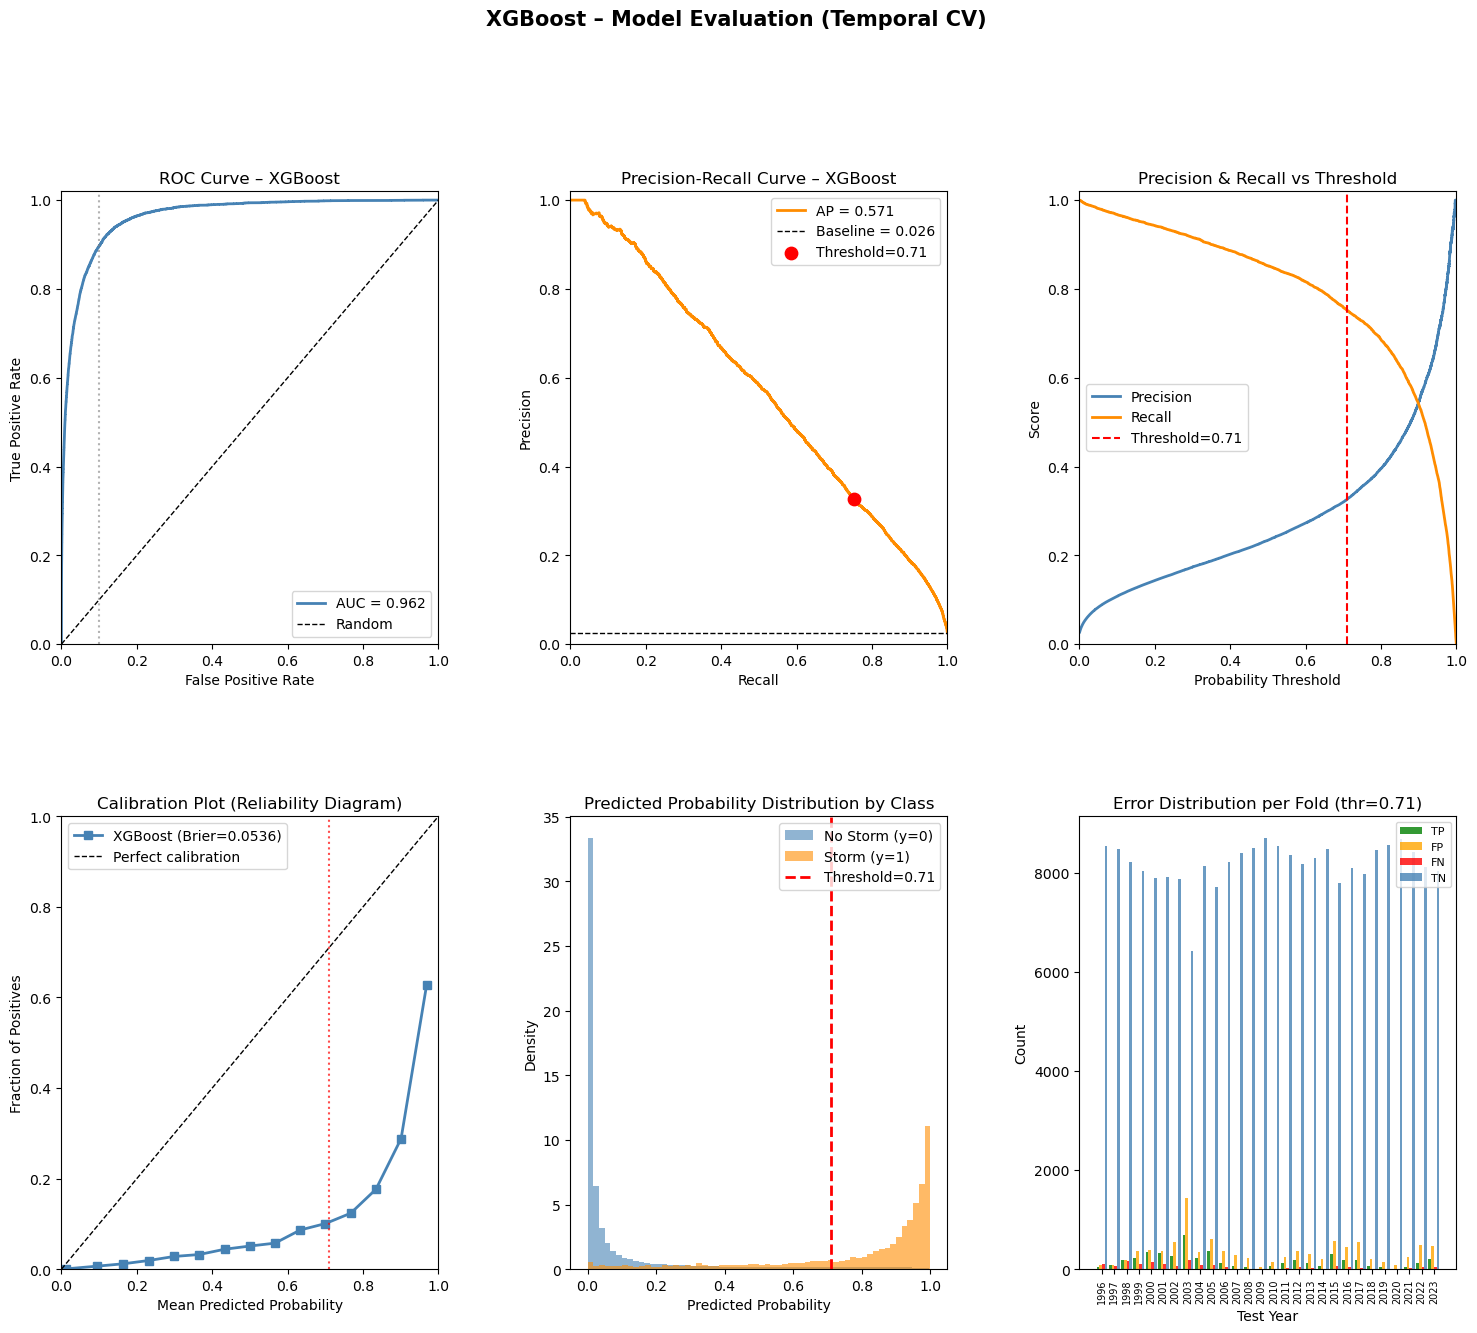


Aggregate OOF Metrics (threshold=0.7100):
  ROC-AUC        : 0.9620
  Avg Precision  : 0.5706
  Brier Score    : 0.0536
  Overall Precision: 0.3260
  Overall Recall : 0.7517


In [8]:
from xgboost import XGBClassifier
from src.models.train import train_on_temporal_splits, test_on_temporal_splits
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Best params from Optuna
xgb_best_params = {

    'max_depth':5,            
    'learning_rate':0.111,     
    'scale_pos_weight':scale_weight,
    'eval_metric':'logloss',
    'random_state':42}
best_prob_threshold = 0.71

# Train models on temporal splits
xgb_models = train_on_temporal_splits(XGBClassifier, xgb_best_params, preprocessed_Xs, preprocessed_ys)

# Collect all OOF probabilities and true labels for aggregate plots
all_probs = []
all_trues = []
all_preds_binary = []

# Also get per-fold predictions using threshold
preds = test_on_temporal_splits(xgb_models, preprocessed_Xs, preprocessed_ys, best_prob_threshold)

# Gather raw probabilities from each fold (test on last fold per model)
n_splits = len(xgb_models)
for fold_idx, model in enumerate(xgb_models):
    # Test fold is the fold right after training folds
    test_idx = fold_idx + 1  # temporal split: train on 0..fold_idx, test on fold_idx+1
    if test_idx < len(preprocessed_Xs):
        X_test = preprocessed_Xs[test_idx]
        y_test = preprocessed_ys[test_idx]
        proba = model.predict_proba(X_test)[:, 1]
        all_probs.extend(proba)
        all_trues.extend(y_test.astype(int).values)
        all_preds_binary.extend((proba >= best_prob_threshold).astype(int))

all_probs = np.array(all_probs)
all_trues = np.array(all_trues)
all_preds_binary = np.array(all_preds_binary)

# ── Figure Setup ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# ── 1. ROC Curve ──────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(all_trues, all_probs)
roc_auc = auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax_roc.axvline(x=0.1, color='gray', linestyle=':', alpha=0.6)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve – XGBoost')
ax_roc.legend(loc='lower right')
ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])

# ── 2. Precision-Recall Curve ─────────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[0, 1])
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(all_trues, all_probs)
ap = average_precision_score(all_trues, all_probs)
ax_pr.plot(recall_vals, precision_vals, color='darkorange', lw=2, label=f'AP = {ap:.3f}')
baseline = all_trues.mean()
ax_pr.axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.3f}')
# Mark operating threshold
op_idx = np.argmin(np.abs(thresholds_pr - best_prob_threshold))
ax_pr.scatter(recall_vals[op_idx], precision_vals[op_idx],
              color='red', zorder=5, s=80, label=f'Threshold={best_prob_threshold:.2f}')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve – XGBoost')
ax_pr.legend(loc='upper right')
ax_pr.set_xlim([0, 1]); ax_pr.set_ylim([0, 1.02])

# ── 3. Precision & Recall vs Threshold ────────────────────────────────────────
ax_thr = fig.add_subplot(gs[0, 2])
ax_thr.plot(thresholds_pr, precision_vals[:-1], color='steelblue', lw=2, label='Precision')
ax_thr.plot(thresholds_pr, recall_vals[:-1], color='darkorange', lw=2, label='Recall')
ax_thr.axvline(x=best_prob_threshold, color='red', linestyle='--', lw=1.5, label=f'Threshold={best_prob_threshold:.2f}')
ax_thr.set_xlabel('Probability Threshold')
ax_thr.set_ylabel('Score')
ax_thr.set_title('Precision & Recall vs Threshold')
ax_thr.legend()
ax_thr.set_xlim([0, 1]); ax_thr.set_ylim([0, 1.02])

# ── 4. Calibration Plot ───────────────────────────────────────────────────────
ax_cal = fig.add_subplot(gs[1, 0])
fraction_of_positives, mean_predicted_value = calibration_curve(all_trues, all_probs, n_bins=15)
brier = brier_score_loss(all_trues, all_probs)
ax_cal.plot(mean_predicted_value, fraction_of_positives,
            's-', color='steelblue', lw=2, label=f'XGBoost (Brier={brier:.4f})')
ax_cal.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax_cal.axvline(x=best_prob_threshold, color='red', linestyle=':', lw=1.5, alpha=0.7)
ax_cal.set_xlabel('Mean Predicted Probability')
ax_cal.set_ylabel('Fraction of Positives')
ax_cal.set_title('Calibration Plot (Reliability Diagram)')
ax_cal.legend()
ax_cal.set_xlim([0, 1]); ax_cal.set_ylim([0, 1])

# ── 5. Predicted Probability Distribution ─────────────────────────────────────
ax_dist = fig.add_subplot(gs[1, 1])
storm_probs = all_probs[all_trues == 1]
no_storm_probs = all_probs[all_trues == 0]
ax_dist.hist(no_storm_probs, bins=60, alpha=0.6, color='steelblue',
             density=True, label='No Storm (y=0)')
ax_dist.hist(storm_probs, bins=60, alpha=0.6, color='darkorange',
             density=True, label='Storm (y=1)')
ax_dist.axvline(x=best_prob_threshold, color='red', linestyle='--',
                lw=2, label=f'Threshold={best_prob_threshold:.2f}')
ax_dist.set_xlabel('Predicted Probability')
ax_dist.set_ylabel('Density')
ax_dist.set_title('Predicted Probability Distribution by Class')
ax_dist.legend()

# ── 6. Error Distribution (FP/FN/TP/TN per fold) ─────────────────────────────
ax_err = fig.add_subplot(gs[1, 2])
fold_labels, tps, fps, tns, fns = [], [], [], [], []

for fold_idx, model in enumerate(xgb_models):
    test_idx = fold_idx + 1
    if test_idx < len(preprocessed_Xs):
        X_test = preprocessed_Xs[test_idx]
        y_test = preprocessed_ys[test_idx].astype(int).values
        proba = model.predict_proba(X_test)[:, 1]
        y_pred = (proba >= best_prob_threshold).astype(int)
        tp = int(((y_pred == 1) & (y_test == 1)).sum())
        fp = int(((y_pred == 1) & (y_test == 0)).sum())
        tn = int(((y_pred == 0) & (y_test == 0)).sum())
        fn = int(((y_pred == 0) & (y_test == 1)).sum())
        tps.append(tp); fps.append(fp); tns.append(tn); fns.append(fn)
        fold_labels.append(f'{years[test_idx]}')

x_pos = np.arange(len(fold_labels))
width = 0.22
ax_err.bar(x_pos - 1.5*width, tps, width, label='TP', color='green', alpha=0.8)
ax_err.bar(x_pos - 0.5*width, fps, width, label='FP', color='orange', alpha=0.8)
ax_err.bar(x_pos + 0.5*width, fns, width, label='FN', color='red', alpha=0.8)
ax_err.bar(x_pos + 1.5*width, tns, width, label='TN', color='steelblue', alpha=0.8)
ax_err.set_xticks(x_pos)
ax_err.set_xticklabels(fold_labels, rotation=90, fontsize=7)
ax_err.set_xlabel('Test Year')
ax_err.set_ylabel('Count')
ax_err.set_title(f'Error Distribution per Fold (thr={best_prob_threshold:.2f})')
ax_err.legend(loc='upper right', fontsize=8)

fig.suptitle('XGBoost – Model Evaluation (Temporal CV)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\nAggregate OOF Metrics (threshold={best_prob_threshold:.4f}):")
print(f"  ROC-AUC        : {roc_auc:.4f}")
print(f"  Avg Precision  : {ap:.4f}")
print(f"  Brier Score    : {brier:.4f}")
print(f"  Overall Precision: {(all_preds_binary[all_trues==1].sum() / all_preds_binary.sum()):.4f}" if all_preds_binary.sum() > 0 else "  No positive predictions")
print(f"  Overall Recall : {(all_preds_binary[all_trues==1].sum() / all_trues.sum()):.4f}")

## LightGBM

In [5]:
import optuna
from lightgbm import LGBMClassifier
# Assuming these imports exist in your source
from src.models.train import (
    class_weight_across_folds, 
    train_on_temporal_splits, 
    test_on_temporal_splits,
    evaluate_on_temporal_splits
)

# Calculate scale weight once outside the objective
scale_weight = class_weight_across_folds(preprocessed_ys)

def objective(trial):
    # 1. Suggest LGBM-specific hyperparameters
    # LightGBM is leaf-wise; num_leaves should be <= 2^max_depth
    max_depth = trial.suggest_int("max_depth", 3, 12)
    num_leaves = trial.suggest_int("num_leaves", 8, 256)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    
    # Probability threshold for the .predict_proba() step
    prob_thres = trial.suggest_float("prob_threshold", 0.10, 0.90) 
    
    # Regulators to help with the 0.3 precision constraint (prevent overfitting)
    lambda_l1 = trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True)
    lambda_l2 = trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True)

    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": 42,
        "max_depth": max_depth,
        "num_leaves": num_leaves,
        "learning_rate": learning_rate,
        "scale_pos_weight": scale_weight,
        "lambda_l1": lambda_l1,
        "lambda_l2": lambda_l2,
        "n_jobs": -1
    }

    # 2. Train using your temporal split logic
    # We pass LGBMClassifier instead of XGBClassifier
    models = train_on_temporal_splits(LGBMClassifier, params, preprocessed_Xs, preprocessed_ys)
    
    # 3. Generate predictions and evaluate
    preds = test_on_temporal_splits(models, preprocessed_Xs, preprocessed_ys, prob_thres)
    summary = evaluate_on_temporal_splits(preds)

    # 4. Extract metrics from your summary object
    # Note: Using your existing logic to pull from the summary dictionary
    mean_precision = summary.get('Mean precisions') 
    mean_recall = summary.get('Mean recalls')

    if mean_precision is None or mean_recall is None:
        # Fallback if keys are slightly different in your evaluate function
        mean_precision = _extract_metric(summary, ['Mean precisions', 'precision'])
        mean_recall = _extract_metric(summary, ['Mean recalls', 'recall'])

    # Log for inspection
    trial.set_user_attr("mean_precision", mean_precision)
    trial.set_user_attr("mean_recall", mean_recall)

    # 5. Objective: Maximize Recall SUBJECT TO Precision >= 0.30
    # If precision is too low, we return a "penalty" value (0.0)
    if mean_precision < 0.30:
        return 0.0
    
    return mean_recall

# Create and run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Results
best = study.best_trial
print(f"\nOptimization Finished:")
print(f"Best Mean Recall (where Precision >= 0.3): {best.value:.4f}")
print(f"Best Params: {best.params}")
print(f"Associated Precision: {best.user_attrs.get('mean_precision'):.4f}")

/Users/ghseeli/spring-2026-electromagnetic-risk-prediction/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-21 21:02:27,688] A new study created in memory with name: no-name-05eb6706-9043-458d-b877-bccd3c6d2bce
[I 2026-03-21 21:03:39,881] Trial 0 finished with value: 0.0 and parameters: {'max_depth': 10, 'num_leaves': 217, 'learning_rate': 0.036002840841970835, 'prob_threshold': 0.4199075075491777, 'lambda_l1': 3.443211256609232e-07, 'lambda_l2': 1.288911498750265}. Best is trial 0 with value: 0.0.
[I 2026-03-21 21:04:35,729] Trial 1 finished with value: 0.0 and parameters: {'max_depth': 11, 'num_leaves': 121, 'learning_rate': 0.0011430882722393571, 'prob_threshold': 0.5772688164980194, 'lambda_l1': 2.1988957988531994e-06, 'lambda_l2': 0.00024129355259571467}. Best is trial 0 with value


Optimization Finished:
Best Mean Recall (where Precision >= 0.3): 0.7445
Best Params: {'max_depth': 6, 'num_leaves': 143, 'learning_rate': 0.13200363409601076, 'prob_threshold': 0.6583570443206297, 'lambda_l1': 2.1901087796349796, 'lambda_l2': 0.000499997639085018}
Associated Precision: 0.3046


This Optuna run found optimal LightBGM model with parameters

`{'max_depth': 6, 'num_leaves': 143, 'learning_rate': 0.13200363409601076, 'prob_threshold': 0.6583570443206297, 'lambda_l1': 2.1901087796349796, 'lambda_l2': 0.000499997639085018}`

/var/folders/_v/rxjyhj5s2gs85glvfgzgxpd40000gn/T/ipykernel_46846/3551539605.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


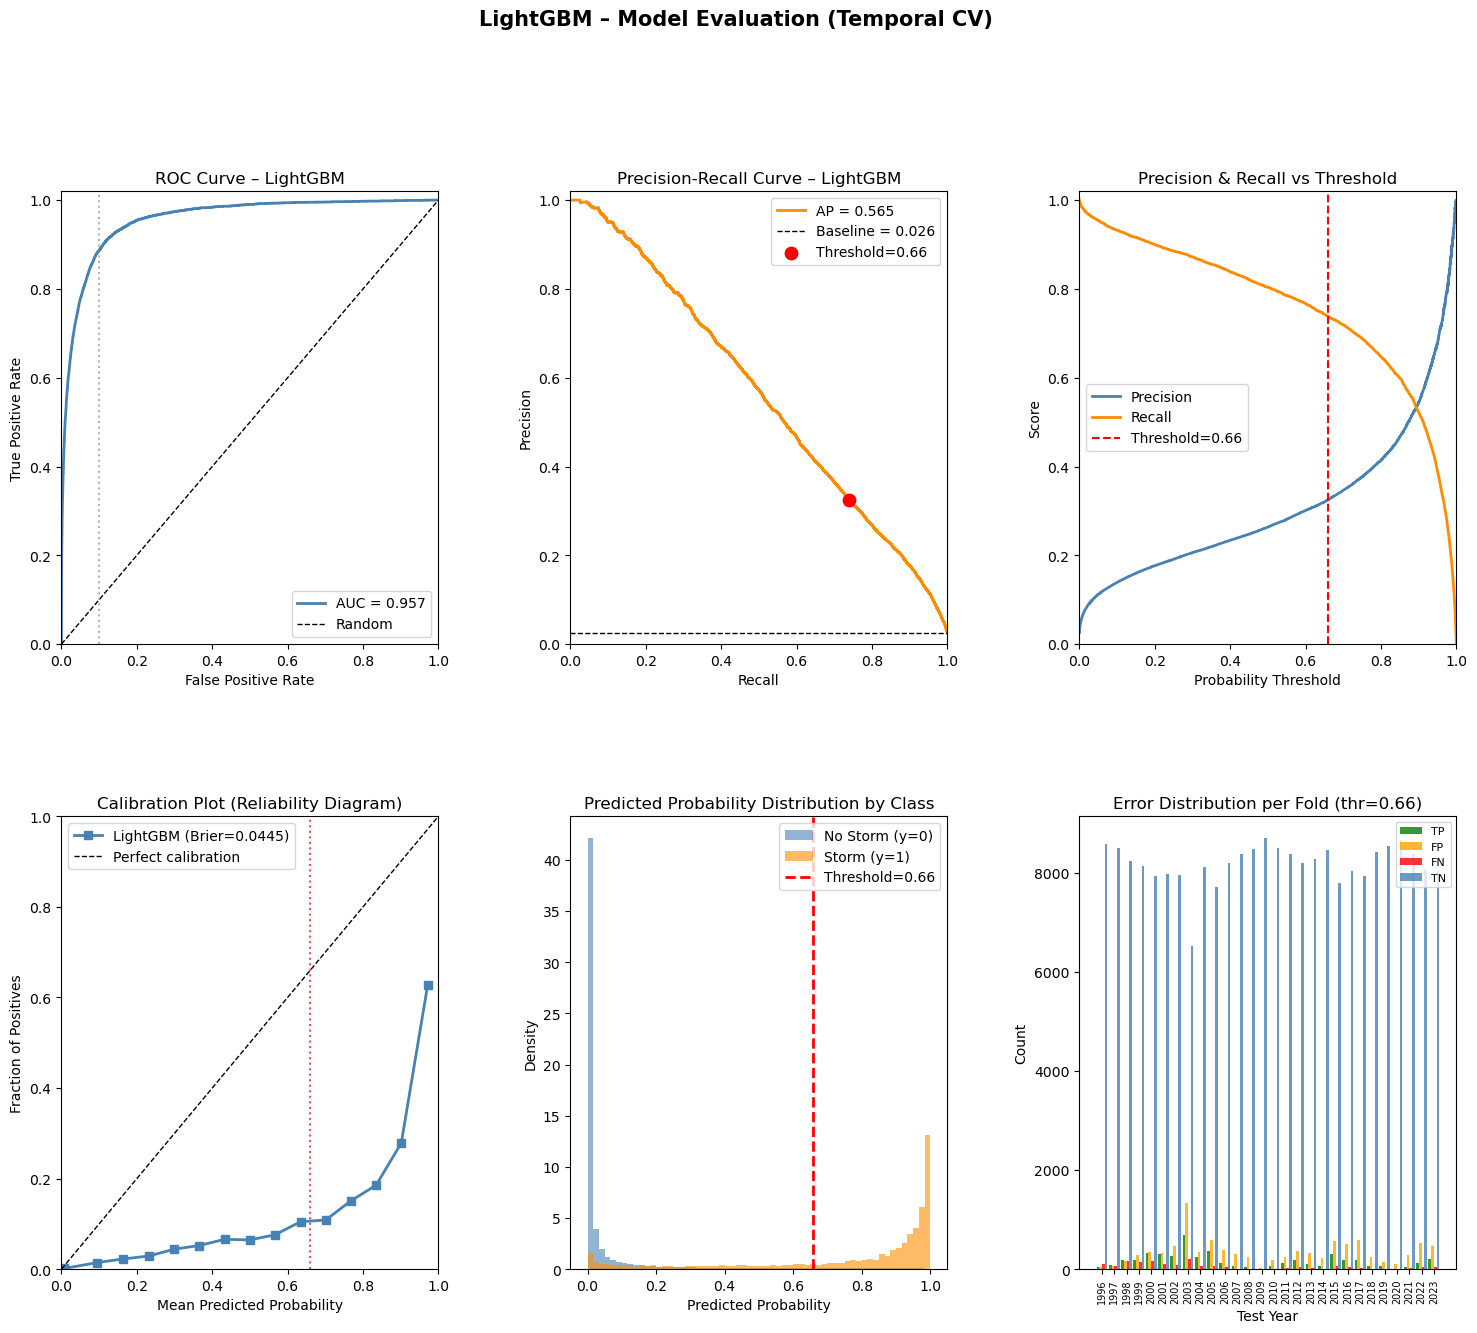


Aggregate OOF Metrics (threshold=0.6584):
  ROC-AUC        : 0.9567
  Avg Precision  : 0.5647
  Brier Score    : 0.0445
  Overall Precision: 0.3246
  Overall Recall : 0.7389


In [6]:
from lightgbm import LGBMClassifier
from src.models.train import train_on_temporal_splits, test_on_temporal_splits
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Best params from Optuna
lgbm_best_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "random_state": 42,
    "max_depth": 6,
    "num_leaves": 143,
    "learning_rate": 0.13200363409601076,
    "scale_pos_weight": scale_weight,
    "lambda_l1": 2.1901087796349796,
    "lambda_l2": 0.000499997639085018,
    "n_jobs": -1
}
best_prob_threshold = 0.6583570443206297

# Train models on temporal splits
lgbm_models = train_on_temporal_splits(LGBMClassifier, lgbm_best_params, preprocessed_Xs, preprocessed_ys)

# Collect all OOF probabilities and true labels for aggregate plots
all_probs = []
all_trues = []
all_preds_binary = []

# Also get per-fold predictions using threshold
preds = test_on_temporal_splits(lgbm_models, preprocessed_Xs, preprocessed_ys, best_prob_threshold)

# Gather raw probabilities from each fold (test on last fold per model)
n_splits = len(lgbm_models)
for fold_idx, model in enumerate(lgbm_models):
    # Test fold is the fold right after training folds
    test_idx = fold_idx + 1  # temporal split: train on 0..fold_idx, test on fold_idx+1
    if test_idx < len(preprocessed_Xs):
        X_test = preprocessed_Xs[test_idx]
        y_test = preprocessed_ys[test_idx]
        proba = model.predict_proba(X_test)[:, 1]
        all_probs.extend(proba)
        all_trues.extend(y_test.astype(int).values)
        all_preds_binary.extend((proba >= best_prob_threshold).astype(int))

all_probs = np.array(all_probs)
all_trues = np.array(all_trues)
all_preds_binary = np.array(all_preds_binary)

# ── Figure Setup ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# ── 1. ROC Curve ──────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(all_trues, all_probs)
roc_auc = auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax_roc.axvline(x=0.1, color='gray', linestyle=':', alpha=0.6)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve – LightGBM')
ax_roc.legend(loc='lower right')
ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])

# ── 2. Precision-Recall Curve ─────────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[0, 1])
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(all_trues, all_probs)
ap = average_precision_score(all_trues, all_probs)
ax_pr.plot(recall_vals, precision_vals, color='darkorange', lw=2, label=f'AP = {ap:.3f}')
baseline = all_trues.mean()
ax_pr.axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.3f}')
# Mark operating threshold
op_idx = np.argmin(np.abs(thresholds_pr - best_prob_threshold))
ax_pr.scatter(recall_vals[op_idx], precision_vals[op_idx],
              color='red', zorder=5, s=80, label=f'Threshold={best_prob_threshold:.2f}')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve – LightGBM')
ax_pr.legend(loc='upper right')
ax_pr.set_xlim([0, 1]); ax_pr.set_ylim([0, 1.02])

# ── 3. Precision & Recall vs Threshold ────────────────────────────────────────
ax_thr = fig.add_subplot(gs[0, 2])
ax_thr.plot(thresholds_pr, precision_vals[:-1], color='steelblue', lw=2, label='Precision')
ax_thr.plot(thresholds_pr, recall_vals[:-1], color='darkorange', lw=2, label='Recall')
ax_thr.axvline(x=best_prob_threshold, color='red', linestyle='--', lw=1.5, label=f'Threshold={best_prob_threshold:.2f}')
ax_thr.set_xlabel('Probability Threshold')
ax_thr.set_ylabel('Score')
ax_thr.set_title('Precision & Recall vs Threshold')
ax_thr.legend()
ax_thr.set_xlim([0, 1]); ax_thr.set_ylim([0, 1.02])

# ── 4. Calibration Plot ───────────────────────────────────────────────────────
ax_cal = fig.add_subplot(gs[1, 0])
fraction_of_positives, mean_predicted_value = calibration_curve(all_trues, all_probs, n_bins=15)
brier = brier_score_loss(all_trues, all_probs)
ax_cal.plot(mean_predicted_value, fraction_of_positives,
            's-', color='steelblue', lw=2, label=f'LightGBM (Brier={brier:.4f})')
ax_cal.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax_cal.axvline(x=best_prob_threshold, color='red', linestyle=':', lw=1.5, alpha=0.7)
ax_cal.set_xlabel('Mean Predicted Probability')
ax_cal.set_ylabel('Fraction of Positives')
ax_cal.set_title('Calibration Plot (Reliability Diagram)')
ax_cal.legend()
ax_cal.set_xlim([0, 1]); ax_cal.set_ylim([0, 1])

# ── 5. Predicted Probability Distribution ─────────────────────────────────────
ax_dist = fig.add_subplot(gs[1, 1])
storm_probs = all_probs[all_trues == 1]
no_storm_probs = all_probs[all_trues == 0]
ax_dist.hist(no_storm_probs, bins=60, alpha=0.6, color='steelblue',
             density=True, label='No Storm (y=0)')
ax_dist.hist(storm_probs, bins=60, alpha=0.6, color='darkorange',
             density=True, label='Storm (y=1)')
ax_dist.axvline(x=best_prob_threshold, color='red', linestyle='--',
                lw=2, label=f'Threshold={best_prob_threshold:.2f}')
ax_dist.set_xlabel('Predicted Probability')
ax_dist.set_ylabel('Density')
ax_dist.set_title('Predicted Probability Distribution by Class')
ax_dist.legend()

# ── 6. Error Distribution (FP/FN/TP/TN per fold) ─────────────────────────────
ax_err = fig.add_subplot(gs[1, 2])
fold_labels, tps, fps, tns, fns = [], [], [], [], []

for fold_idx, model in enumerate(lgbm_models):
    test_idx = fold_idx + 1
    if test_idx < len(preprocessed_Xs):
        X_test = preprocessed_Xs[test_idx]
        y_test = preprocessed_ys[test_idx].astype(int).values
        proba = model.predict_proba(X_test)[:, 1]
        y_pred = (proba >= best_prob_threshold).astype(int)
        tp = int(((y_pred == 1) & (y_test == 1)).sum())
        fp = int(((y_pred == 1) & (y_test == 0)).sum())
        tn = int(((y_pred == 0) & (y_test == 0)).sum())
        fn = int(((y_pred == 0) & (y_test == 1)).sum())
        tps.append(tp); fps.append(fp); tns.append(tn); fns.append(fn)
        fold_labels.append(f'{years[test_idx]}')

x_pos = np.arange(len(fold_labels))
width = 0.22
ax_err.bar(x_pos - 1.5*width, tps, width, label='TP', color='green', alpha=0.8)
ax_err.bar(x_pos - 0.5*width, fps, width, label='FP', color='orange', alpha=0.8)
ax_err.bar(x_pos + 0.5*width, fns, width, label='FN', color='red', alpha=0.8)
ax_err.bar(x_pos + 1.5*width, tns, width, label='TN', color='steelblue', alpha=0.8)
ax_err.set_xticks(x_pos)
ax_err.set_xticklabels(fold_labels, rotation=90, fontsize=7)
ax_err.set_xlabel('Test Year')
ax_err.set_ylabel('Count')
ax_err.set_title(f'Error Distribution per Fold (thr={best_prob_threshold:.2f})')
ax_err.legend(loc='upper right', fontsize=8)

fig.suptitle('LightGBM – Model Evaluation (Temporal CV)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\nAggregate OOF Metrics (threshold={best_prob_threshold:.4f}):")
print(f"  ROC-AUC        : {roc_auc:.4f}")
print(f"  Avg Precision  : {ap:.4f}")
print(f"  Brier Score    : {brier:.4f}")
print(f"  Overall Precision: {(all_preds_binary[all_trues==1].sum() / all_preds_binary.sum()):.4f}" if all_preds_binary.sum() > 0 else "  No positive predictions")
print(f"  Overall Recall : {(all_preds_binary[all_trues==1].sum() / all_trues.sum()):.4f}")